In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import f2D_utilities as utils;
from matplotlib.animation import FuncAnimation;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_10/DN_RHTEST_A3_QUIESCENT";
data_arrays = reader.fetch_f2D_data(directory_path, parallelise = True);

Found 2001 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    6.5s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:    9.9s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:   13.9s
[Parallel(n_jobs=16)]: Done 2001 out of 2001 | elapsed:   15.7s finished


Finished compiling data from all files in the directory.


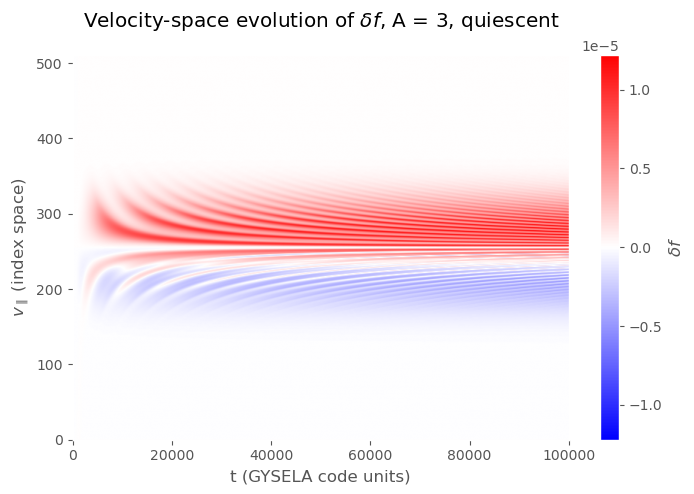

In [3]:
def plot_velocity_evolution(f2D_list, dt_diag, title_suffix = ""):

	vpar, delta_f_vpar_time = utils.compute_delta_f_vpar(f2D_list);
	time_range = np.arange(len(delta_f_vpar_time)) * dt_diag;
	
	plt.figure(figsize=(8, 5));
	plt.imshow(
		delta_f_vpar_time.T,
		aspect = "auto",
		origin = "lower",
		extent = [time_range[0], time_range[-1], vpar[0], vpar[-1]],
		cmap = "bwr",
		vmin = -np.max(np.abs(delta_f_vpar_time)),
		vmax =  np.max(np.abs(delta_f_vpar_time)),
	);
	plt.title(rf"Velocity-space evolution of $\delta f$, {title_suffix}", pad = 20);
	plt.xlabel("t (GYSELA code units)");
	plt.ylabel(r"$v_\parallel$ (index space)");
	plt.colorbar(label = r"$\delta f$");
	plt.grid(False);
	plt.show();

plot_velocity_evolution(data_arrays, dt_diag = 50, title_suffix = "A = 3, quiescent");